# Principal Components Analysis (PCA) in R

## Overview

PCA reduces a high-dimensional dataset to a smaller set of uncorrelated axes (principal components) that capture the most variance. It is an **unconstrained ordination** — the axes are determined entirely by the data, with no reference to grouping variables or environmental predictors.

| Term | Meaning |
|---|---|
| **Principal component (PC)** | A new axis that is a linear combination of the original variables |
| **Eigenvalue** | The variance explained by each PC |
| **Loadings** | Contribution of each original variable to a PC — indicates which variables drive each axis |
| **Scores** | The position of each observation on the PC axes |
| **Biplot** | Combined plot of scores and loadings — shows observations and variables in the same ordination space |

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Summarizing a multivariate water chemistry panel into a few axes for use as predictors; visualizing how sites differ in environmental space |
| **Healthcare** | Reducing correlated clinical biomarkers to uncorrelated components; visualizing patient clusters in high-dimensional measurement space |
| **Finance** | Summarizing correlated financial ratios; factor analysis of portfolio characteristics |
| **Insurance** | Reducing correlated policyholder variables; identifying latent risk dimensions |

---

## Assumptions Checklist

- [ ] **Continuous variables:** PCA is designed for continuous data; binary or count data requires special handling
- [ ] **Linear relationships:** PCA captures linear covariance structure; non-linear structure is not captured
- [ ] **Variables are scaled:** If variables are on different scales, standardize (`scale = TRUE`) before PCA
- [ ] **No extreme outliers:** Outliers have disproportionate influence on PCA axes
- [ ] **Sufficient sample size:** A rough guideline: at least 5-10 observations per variable

> **For community/species composition data:** Use Hellinger-transformed PCA (`vegan::rda()` after `decostand()`) or NMDS/PCoA instead of standard PCA — standard PCA on species data suffers from the arch effect and double-zero problem.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)        # rda() for PCA on community data
library(ggfortify)    # autoplot() for PCA objects
library(factoextra)   # fviz_pca_*() for visualization
library(patchwork)

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute

Warning message:
"package 'ggfo

## Data

We use two datasets:
1. **Environmental variables** — a correlated panel of water chemistry measurements across sites (appropriate for standard PCA)
2. **Hellinger-transformed species data** — appropriate for PCA via `vegan::rda()`

In [2]:
# ── Simulate water chemistry data (environmental PCA) ────────────────────────
n_sites <- 60
env_data <- tibble(
  site       = paste0("site", 1:n_sites),
  habitat    = rep(c("reference", "degraded", "restored"), each = 20),
  pH         = c(rnorm(20, 7.8, 0.3), rnorm(20, 6.5, 0.6), rnorm(20, 7.2, 0.4)),
  dissolved_O2 = c(rnorm(20, 9.5, 0.8), rnorm(20, 6.5, 1.5), rnorm(20, 8.2, 1.0)),
  turbidity  = c(rnorm(20, 3, 1), rnorm(20, 12, 3), rnorm(20, 6, 2)),
  nitrate    = c(rnorm(20, 0.5, 0.2), rnorm(20, 3.5, 1.0), rnorm(20, 1.5, 0.5)),
  phosphate  = c(rnorm(20, 0.05, 0.02), rnorm(20, 0.3, 0.1), rnorm(20, 0.12, 0.05)),
  conductivity = c(rnorm(20, 250, 30), rnorm(20, 450, 80), rnorm(20, 320, 50))
)

# Numeric matrix for PCA
env_mat <- env_data %>%
  select(pH, dissolved_O2, turbidity, nitrate, phosphate, conductivity) %>%
  as.matrix()
rownames(env_mat) <- env_data$site

cat(sprintf("Environmental matrix: %d sites × %d variables\n",
            nrow(env_mat), ncol(env_mat)))

Environmental matrix: 60 sites × 6 variables


---

## Fitting PCA

In [3]:
# ── Base R prcomp() ───────────────────────────────────────────────────────────
pca_result <- prcomp(env_mat, scale. = TRUE, center = TRUE)
# scale. = TRUE: standardizes all variables to mean=0, SD=1
#   → ALWAYS use when variables are on different scales
# center = TRUE: centers variables at their mean (default)

# ── Summary: variance explained ───────────────────────────────────────────────
summary(pca_result)
# Proportion of Variance: % variance explained by each PC
# Cumulative Proportion: running total

# ── Eigenvalues ───────────────────────────────────────────────────────────────
eigenvalues <- pca_result$sdev^2
pct_var <- eigenvalues / sum(eigenvalues) * 100

tibble(
  PC    = paste0("PC", 1:length(eigenvalues)),
  eigenvalue  = round(eigenvalues, 3),
  pct_var     = round(pct_var, 1),
  cumulative  = round(cumsum(pct_var), 1)
) %>% head(6) %>% print()

# ── Loadings (variable contributions to each PC) ──────────────────────────────
round(pca_result$rotation[, 1:3], 3)
# Large absolute loading: variable strongly associated with that PC
# Sign: direction of association

Importance of components:
                          PC1     PC2     PC3     PC4     PC5     PC6
Standard deviation     2.1077 0.71507 0.62096 0.52234 0.47456 0.40320
Proportion of Variance 0.7404 0.08522 0.06427 0.04547 0.03753 0.02709
Cumulative Proportion  0.7404 0.82563 0.88990 0.93537 0.97291 1.00000

# A tibble: 6 × 4
  PC    eigenvalue pct_var cumulative
  <chr>      <dbl>   <dbl>      <dbl>
1 PC1        4.44     74         74  
2 PC2        0.511     8.5       82.5
3 PC3        0.386     6.4       88.9
4 PC4        0.273     4.5       93.4
5 PC5        0.225     3.8       97.2
6 PC6        0.163     2.7       99.9


,PC1,PC2,PC3
pH,-0.397,-0.385,0.700
dissolved_O2,-0.389,0.669,0.226
turbidity,0.415,0.189,0.252
nitrate,0.418,-0.376,-0.094
phosphate,0.418,0.476,0.115
conductivity,0.412,-0.031,0.611


---

## How Many Components?

Three common rules — use them together rather than any one alone.

Kaiser criterion: retain 1 PCs (eigenvalue > 1)
75% variance threshold: retain 2 PCs


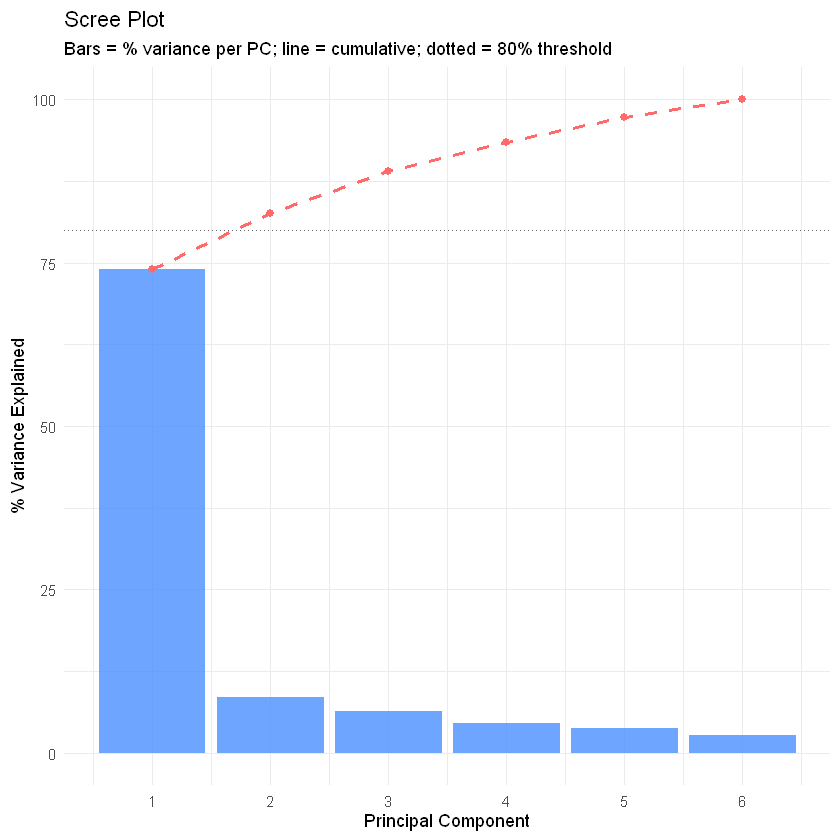

In [4]:
# ── 1. Scree plot: look for the elbow ────────────────────────────────────────
scree_df <- tibble(
  PC         = 1:length(eigenvalues),
  eigenvalue = eigenvalues,
  pct_var    = pct_var
)

p_scree <- ggplot(scree_df, aes(x = PC, y = pct_var)) +
  geom_col(fill = "#4a8fff", alpha = 0.8) +
  geom_line(aes(y = cumsum(pct_var)), color = "#ff6b6b",
            linewidth = 1, linetype = "dashed") +
  geom_point(aes(y = cumsum(pct_var)), color = "#ff6b6b", size = 2) +
  geom_hline(yintercept = 80, linetype = "dotted", color = "gray40") +
  scale_x_continuous(breaks = 1:length(eigenvalues)) +
  labs(title = "Scree Plot",
       subtitle = "Bars = % variance per PC; line = cumulative; dotted = 80% threshold",
       x = "Principal Component", y = "% Variance Explained") +
  theme_minimal()

# ── 2. Kaiser criterion: retain PCs with eigenvalue > 1 ──────────────────────
# (when using correlation matrix / scaled data)
kaiser_pcs <- sum(eigenvalues > 1)
cat(sprintf("Kaiser criterion: retain %d PCs (eigenvalue > 1)\n", kaiser_pcs))

# ── 3. % variance threshold: retain enough PCs to explain 70-80% ─────────────
threshold_pcs <- which(cumsum(pct_var) >= 75)[1]
cat(sprintf("75%% variance threshold: retain %d PCs\n", threshold_pcs))

print(p_scree)

---

## Biplots

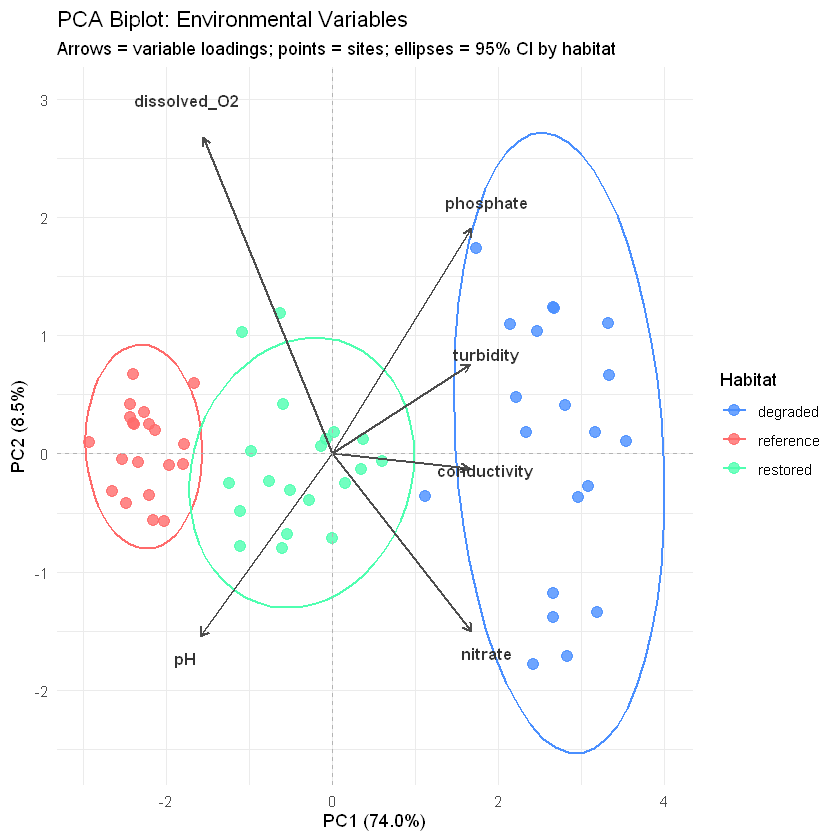

In [5]:
# ── ggplot2 biplot ─────────────────────────────────────────────────────────────
scores_df <- as.data.frame(pca_result$x[, 1:2]) %>%
  rownames_to_column("site") %>%
  left_join(env_data %>% select(site, habitat), by = "site")

# Scale loadings for biplot display
scale_factor <- 4
loadings_df <- as.data.frame(pca_result$rotation[, 1:2]) %>%
  rownames_to_column("variable") %>%
  mutate(PC1 = PC1 * scale_factor,
         PC2 = PC2 * scale_factor)

pct1 <- round(pct_var[1], 1)
pct2 <- round(pct_var[2], 1)

ggplot() +
  # Site scores
  geom_point(data = scores_df,
             aes(x = PC1, y = PC2, color = habitat),
             size = 3, alpha = 0.8) +
  stat_ellipse(data = scores_df,
               aes(x = PC1, y = PC2, color = habitat),
               level = 0.95, linewidth = 0.8) +
  # Loading arrows
  geom_segment(data = loadings_df,
               aes(x = 0, y = 0, xend = PC1, yend = PC2),
               arrow = arrow(length = unit(0.2, "cm")),
               color = "gray30", linewidth = 0.7) +
  geom_text(data = loadings_df,
            aes(x = PC1 * 1.12, y = PC2 * 1.12, label = variable),
            size = 3.5, fontface = "bold", color = "gray20") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray70") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray70") +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  labs(title = "PCA Biplot: Environmental Variables",
       subtitle = "Arrows = variable loadings; points = sites; ellipses = 95% CI by habitat",
       x = sprintf("PC1 (%.1f%%)", pct1),
       y = sprintf("PC2 (%.1f%%)", pct2),
       color = "Habitat") +
  theme_minimal()

---

## PCA on Community Data: Hellinger Transformation + `vegan::rda()`

For species composition data, use Hellinger transformation before PCA to avoid the arch effect and the double-zero problem.


Call:
rda(X = comm_hell2) 

Partitioning of variance:
              Inertia Proportion
Total          0.2316          1
Unconstrained  0.2316          1

Eigenvalues, and their contribution to the variance 

Importance of components:
                          PC1     PC2     PC3     PC4     PC5      PC6      PC7
Eigenvalue            0.07174 0.06501 0.02131 0.01399 0.01280 0.009702 0.007879
Proportion Explained  0.30976 0.28069 0.09200 0.06040 0.05526 0.041889 0.034020
Cumulative Proportion 0.30976 0.59045 0.68245 0.74284 0.79810 0.839989 0.874009
                          PC8      PC9     PC10     PC11     PC12     PC13
Eigenvalue            0.00621 0.005642 0.005138 0.004376 0.002533 0.002184
Proportion Explained  0.02681 0.024361 0.022187 0.018893 0.010938 0.009431
Cumulative Proportion 0.90082 0.925184 0.947371 0.966264 0.977201 0.986633
                          PC14     PC15
Eigenvalue            0.001798 0.001298
Proportion Explained  0.007764 0.005604
Cumulative Proportion 0.9

Variance explained by first 4 PCs:
 PC1  PC2  PC3  PC4 
31.0 28.1  9.2  6.0 


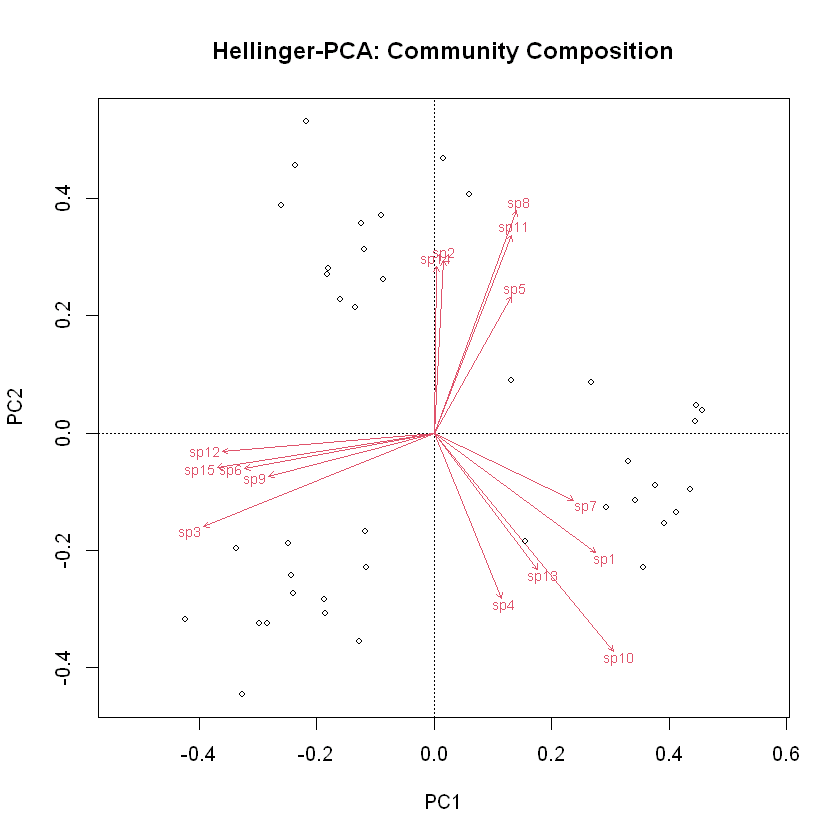

In [6]:
# ── Simulate species matrix ───────────────────────────────────────────────────
n_sites2   <- 40; n_sp <- 15
comm_raw   <- matrix(rpois(n_sites2 * n_sp, lambda = rep(c(5,3,1), length.out = n_sp)),
                     nrow = n_sites2)
rownames(comm_raw) <- paste0("site", 1:n_sites2)
colnames(comm_raw) <- paste0("sp",   1:n_sp)

# ── Hellinger transform then PCA via vegan::rda() ────────────────────────────
comm_hell2 <- vegan::decostand(comm_raw, method = "hellinger")
pca_comm   <- vegan::rda(comm_hell2)  # rda() with no constraints = PCA
summary(pca_comm)

# ── Proportion of variance explained ─────────────────────────────────────────
eigenvals_comm <- vegan::eigenvals(pca_comm)
pct_comm <- eigenvals_comm / sum(eigenvals_comm) * 100
cat("Variance explained by first 4 PCs:\n")
print(round(pct_comm[1:4], 1))

# ── Biplot via vegan ──────────────────────────────────────────────────────────
par(mfrow = c(1,1))
biplot(pca_comm,
       display = c("sites", "species"),
       type    = c("text", "points"),
       main    = "Hellinger-PCA: Community Composition")
# For ggplot2 version: see biplots_visualization.ipynb

---

## Reporting Results

In [7]:
# ── Loadings table ────────────────────────────────────────────────────────────
loadings_table <- as.data.frame(pca_result$rotation[, 1:3]) %>%
  round(3)
print(loadings_table)

# ── Variance explained ────────────────────────────────────────────────────────
var_table <- tibble(
  PC         = paste0("PC", 1:3),
  eigenvalue = round(eigenvalues[1:3], 3),
  pct_var    = round(pct_var[1:3], 1),
  cumulative = round(cumsum(pct_var)[1:3], 1)
)
print(var_table)

# Standard reporting format:
# "PCA was conducted on six water chemistry variables (standardized to
#  unit variance). The first two principal components explained XX% and
#  XX% of total variance, respectively (cumulative: XX%). PC1 was
#  strongly associated with nutrient loading (nitrate loading = X.XX,
#  phosphate loading = X.XX) and turbidity (loading = X.XX), representing
#  a water quality gradient. PC2 was associated with dissolved oxygen and
#  pH, potentially reflecting a productivity or buffering capacity axis."

                PC1    PC2    PC3
pH           -0.397 -0.385  0.700
dissolved_O2 -0.389  0.669  0.226
turbidity     0.415  0.189  0.252
nitrate       0.418 -0.376 -0.094
phosphate     0.418  0.476  0.115
conductivity  0.412 -0.031  0.611
# A tibble: 3 × 4
  PC    eigenvalue pct_var cumulative
  <chr>      <dbl>   <dbl>      <dbl>
1 PC1        4.44     74         74  
2 PC2        0.511     8.5       82.5
3 PC3        0.386     6.4       88.9


---

## Common Pitfalls

**1. Not scaling variables with different units**  
PCA maximizes variance. If pH ranges from 6–9 and conductivity from 100–600, conductivity will dominate the first PC simply due to its larger scale. Always use `scale. = TRUE` when variables have different units.

**2. Applying standard PCA directly to species count matrices**  
Raw species counts violate PCA's linear assumptions and produce the arch effect. Always apply Hellinger transformation first, or use PCoA/NMDS with an appropriate distance metric.

**3. Retaining too few or too many components**  
Using only the Kaiser criterion (eigenvalue > 1) can be too conservative or too liberal depending on the dataset. Use all three rules (elbow, Kaiser, variance threshold) together.

**4. Interpreting PC scores as observed variables**  
PC scores are linear combinations of the original variables. They have no inherent units and should be interpreted through their loadings — which original variables drive each axis.

**5. Using PCA for hypothesis testing**  
PCA is exploratory and descriptive, not inferential. Use PERMANOVA, dbRDA, or discriminant analysis to test specific hypotheses about group differences.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*